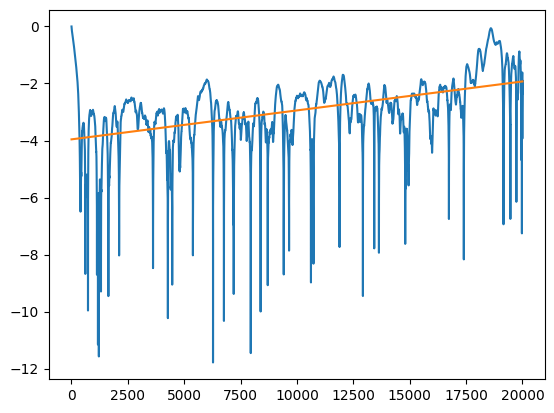

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

np.set_printoptions(precision = 3, suppress = True)

def find_Ck(x,y,z,k):
  sum = 0.0
  N = len(x)
  for i in range(N):
    if i + k >= N:
      break;
    sum += (x[i]*x[i+k] + y[i]*y[i+k] + z[i]*z[i+k])
  return sum/(N-k)

def fit_linear(x,y):
  sum_xy = 0.0
  sum_x = 0.0
  sum_y = 0.0
  sum_x2 = 0.0
  n = len(x)
  for i in range(n):
    sum_xy += x[i]*y[i]
    sum_x += x[i]
    sum_y += y[i]
    sum_x2 += x[i]*x[i]
  m = (n*sum_xy - sum_x*sum_y)/(n*sum_x2 - sum_x**2)
  c = (sum_y - m*sum_x)/n

  return m,c

data = pd.read_csv('/content/lab11_polymer.csv').values
t = data[:,0]
x = data[:,1]
y = data[:,2]
z = data[:,3]
N = len(t)

C = np.zeros(N)
logrho = np.zeros(N)
rho = np.zeros(N)

for i in range(N):
  C[i] = find_Ck(x,y,z,i)
  rho[i] = C[i]/C[0]
  logrho[i] = math.log(abs(rho[i]))


m,c = fit_linear(t,logrho)

plt.plot(t,logrho)
plt.plot(t,m*t+c)
plt.show()


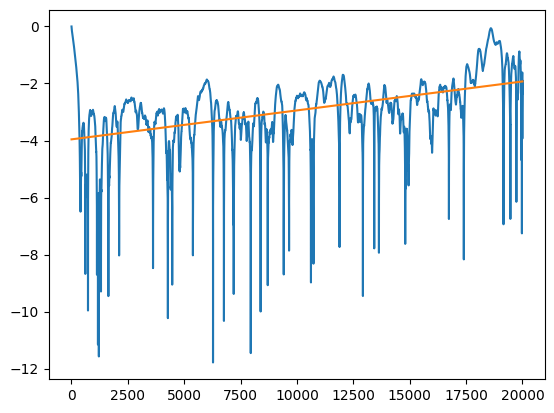

0.00010154956130041927
-3.9597920295767572


In [102]:
data = pd.read_csv('/content/lab11_polymer.csv').values
t = data[:,0]
x = data[:,1]
y = data[:,2]
z = data[:,3]
N = len(t)

m,c = fit_linear(t,logrho)

plt.plot(t,logrho)
plt.plot(t,m*t+c)
plt.show()
print(m)
print(c)

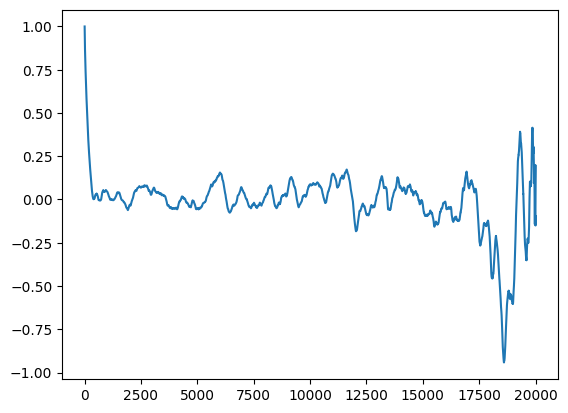

In [ ]:
plt.plot(t,rho)

plt.show()

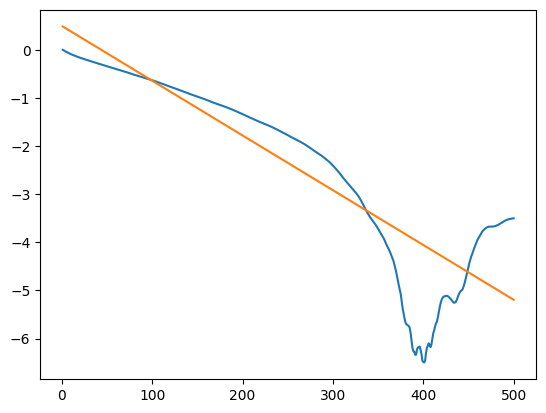

-0.011378386556363078
0.4965296150354316
87.88592258194771


In [104]:


lim = 500
mt,ct = fit_linear(t[:lim],logrho[:lim])
plt.plot(t[:lim],logrho[:lim])
plt.plot(t[:lim],mt*t[:lim]+ct)
plt.show()
print(mt)
print(ct)
tau = -1/mt
print(tau)

In [87]:
from statsmodels.graphics.tsaplots import pacf, plot_pacf

pacf_values = pacf(rho,method='ywadjusted')

print(pacf_values)



[ 1.     0.999 -0.043 -0.03  -0.021 -0.007 -0.003 -0.008 -0.009 -0.011
 -0.015 -0.014 -0.015 -0.011 -0.004 -0.004 -0.004 -0.004 -0.008 -0.005
 -0.005 -0.006 -0.004 -0.004 -0.003 -0.002 -0.004 -0.008 -0.01  -0.014
 -0.016 -0.012 -0.014 -0.014 -0.012 -0.013 -0.013 -0.013 -0.012 -0.01
 -0.007 -0.005 -0.004 -0.004]


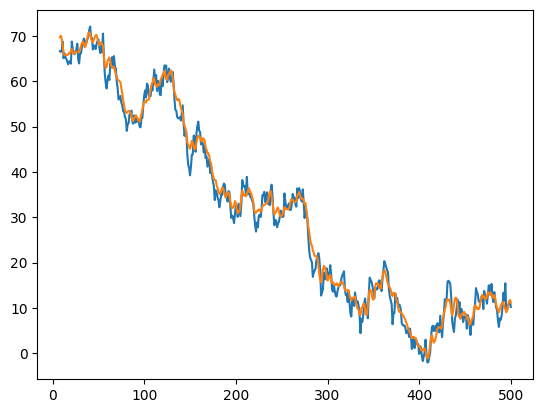

In [94]:
datag = pd.read_csv('/content/lab11_polymer.csv').values
t = datag[:,0]
xg = datag[:,1]

def spenc(X):
  w = [74,67,46,21,3,-5,-6,-3]
  w = np.array(w)/320
  Y = np.zeros(len(X))
  for i in range(len(X)):
    if (i+7)>=len(X):
      break
    for a in range(14):
      Y[i]+=w[a-7]*X[i+a-7]

  return Y

xsm = spenc(xg)

lim2 = 500
plt.plot(t[7:lim2],xg[7:lim2])
plt.plot(t[7:lim2],xsm[7:lim2])
plt.show()

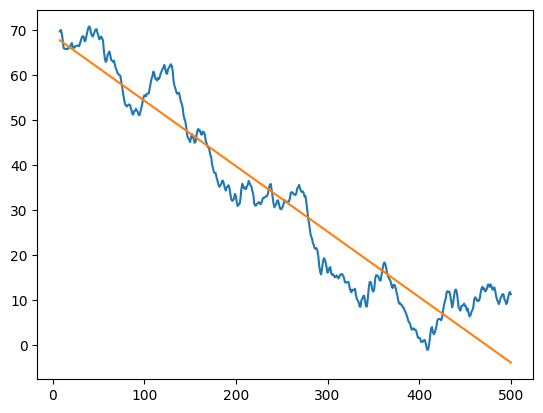

In [95]:
mg,cg = fit_linear(t[7:lim2],xsm[7:lim2])
plt.plot(t[7:lim2],xsm[7:lim2])
plt.plot(t[7:lim2],mg*t[7:lim2]+cg)
plt.show()


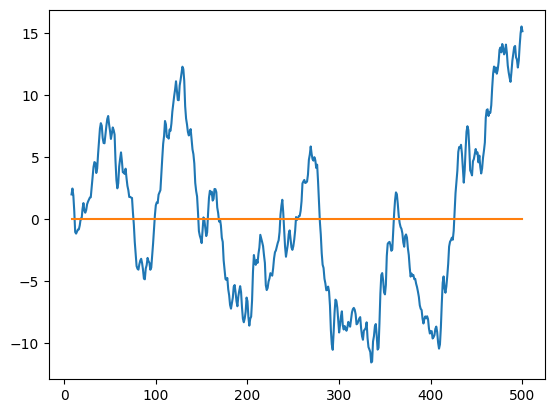

In [97]:
plt.plot(t[7:lim2],xsm[7:lim2]-mg*t[7:lim2]-cg)
plt.plot(t[7:lim2],np.zeros(lim2-7))
plt.show()